# Post-Newtonian Binary Inspiral & Gravitational-Wave Waveform

A two-body system integrated under Newtonian gravity plus the
leading-order (2.5PN) radiation-reaction force -- the mechanism that
turns a fixed ellipse into an inspiral, by draining orbital energy into
gravitational waves. See `GW_Inspiral_Plan.md` for the physics/design.
Validated against the independent Peters (1964) formula, then used to
produce an actual `h+`/`h_x` chirp waveform: first a clean equal-mass
circular case, then GW150914's real published masses. All figures saved
to `media/`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import pn_dynamics as pn
import waveform as wf

MEDIA = "media"
os.makedirs(MEDIA, exist_ok=True)

print(f"length unit = {wf.LENGTH_UNIT_M:.4f} m,  time unit = {wf.TIME_UNIT_S:.4e} s  "
      f"(geometrized solar-mass units, G=c=1, mass in M_sun)")

length unit = 1476.9226 m,  time unit = 4.9264e-06 s  (geometrized solar-mass units, G=c=1, mass in M_sun)


## 1. Validation: measured inspiral rate vs. the Peters (1964) formula

`pn_dynamics.py`'s 2.5PN radiation-reaction force and the Peters
formula are derived two completely different ways (an instantaneous
harmonic-coordinate force law vs. orbit-averaging the GW luminosity) --
agreement here is real evidence the force law's coefficient is right,
not a tautology.

early da/dt:  numeric = -1.196435e-04   Peters = -1.197223e-04   ratio = 0.9993
time to r=6.0M cutoff:  simulated = 1.8956e+06   Peters (to r=0) = 1.8984e+06   ratio = 0.9985
PASS: measured inspiral rate and coalescence time match the independent Peters formula.


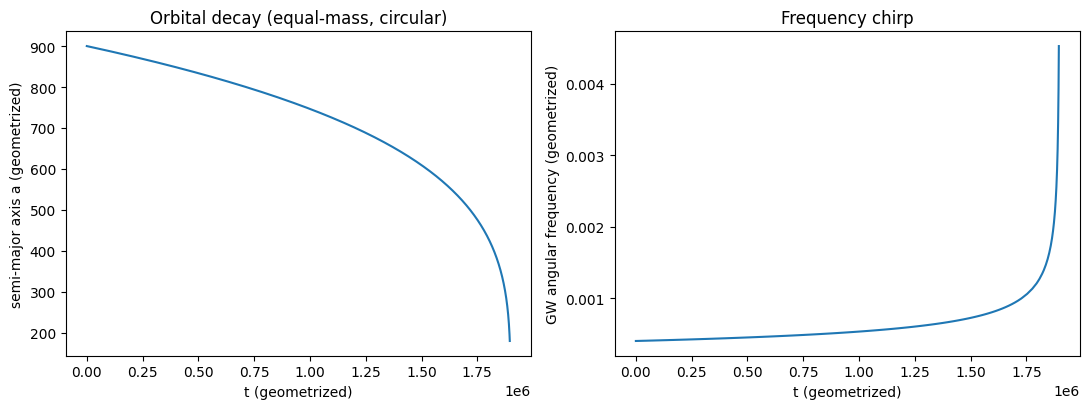

In [2]:
m1, m2 = 15.0, 15.0  # M_sun
M = m1 + m2
a0 = 30.0 * M  # >> M, safely in the PN-valid weak-field regime

res_val = pn.integrate_inspiral(m1, m2, a0, e0=0.0)
a_t = pn.semi_major_axis(res_val["pos"], res_val["vel"], m1, m2)

i0, i1 = 5, 200
dadt_numeric = (a_t[i1] - a_t[i0]) / (res_val["t"][i1] - res_val["t"][i0])
a_mid = 0.5 * (a_t[i0] + a_t[i1])
dadt_peters = pn.peters_dadt(a_mid, m1, m2)
Tc_peters = pn.peters_coalescence_time(a0, m1, m2)

print(f"early da/dt:  numeric = {dadt_numeric:.6e}   Peters = {dadt_peters:.6e}   "
      f"ratio = {dadt_numeric/dadt_peters:.4f}")
print(f"time to r={pn.R_ISCO_CUTOFF_M}M cutoff:  simulated = {res_val['t'][-1]:.4e}   "
      f"Peters (to r=0) = {Tc_peters:.4e}   ratio = {res_val['t'][-1]/Tc_peters:.4f}")

rel_err_dadt = abs(dadt_numeric/dadt_peters - 1.0)
rel_err_Tc = abs(res_val['t'][-1]/Tc_peters - 1.0)
assert rel_err_dadt < 0.01 and rel_err_Tc < 0.05, "should match the Peters formula closely"
print("PASS: measured inspiral rate and coalescence time match the independent Peters formula.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(res_val["t"], a_t)
axes[0].set_xlabel("t (geometrized)"); axes[0].set_ylabel("semi-major axis a (geometrized)")
axes[0].set_title("Orbital decay (equal-mass, circular)")
Om_val = pn.orbital_frequency(res_val["pos"], res_val["vel"])
axes[1].plot(res_val["t"], 2*np.abs(Om_val))
axes[1].set_xlabel("t (geometrized)"); axes[1].set_ylabel("GW angular frequency (geometrized)")
axes[1].set_title("Frequency chirp")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "peters_validation.png"), dpi=150, bbox_inches="tight")
plt.show()

## 2. A clean chirp: equal-mass circular inspiral waveform

`h+`/`h_x` from the quadrupole formula, using the exact
`(pos, vel, acc)` the integrator produced. The characteristic
amplitude-and-frequency "chirp" -- both growing together as the orbit
shrinks -- is the signature LIGO looks for.

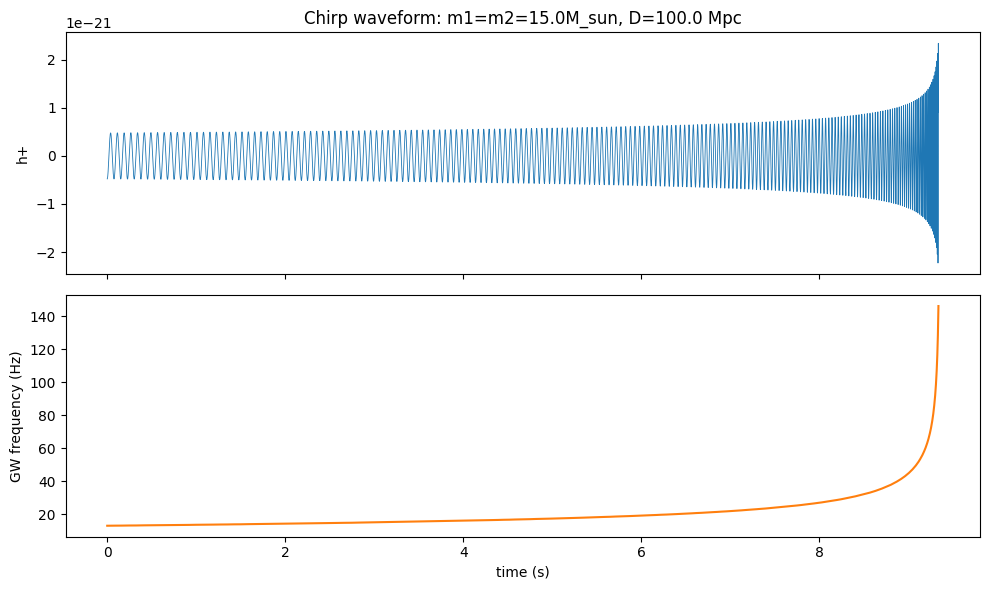

peak |h+| = 2.343e-21  (real GW signals are ~1e-21 at ~100s of Mpc -- right order of magnitude)
frequency range: 13.11 - 146.32 Hz


In [3]:
mu_val = m1*m2/M
D_mpc_demo = 100.0

h_plus, h_cross = wf.strain_plus_cross_SI(res_val["pos"], res_val["vel"], res_val["acc"], mu_val, D_mpc_demo)
t_s = wf.geometrized_to_seconds(res_val["t"])
f_gw_hz = wf.geometrized_freq_to_hz(2*np.abs(Om_val))

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_s, h_plus, lw=0.6)
axes[0].set_ylabel("h+")
axes[0].set_title(f"Chirp waveform: m1=m2={m1}M_sun, D={D_mpc_demo} Mpc")
axes[1].plot(t_s, f_gw_hz, color="C1")
axes[1].set_ylabel("GW frequency (Hz)")
axes[1].set_xlabel("time (s)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "equal_mass_chirp.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"peak |h+| = {np.abs(h_plus).max():.3e}  (real GW signals are ~1e-21 at ~100s of Mpc -- right order of magnitude)")
print(f"frequency range: {f_gw_hz.min():.2f} - {f_gw_hz.max():.2f} Hz")

## 3. GW150914: real event parameters

Published masses `m1~36 M_sun`, `m2~29 M_sun`, luminosity distance
`~410 Mpc`. The inspiral portion (well-described by this leading-order
PN + radiation reaction) should show a physically sensible chirp; the
simulated cutoff sits at `r=6M` -- a conservative "PN is no longer
trustworthy past this point" boundary, well before the true strong
-field merger (which needs higher PN orders or full numerical
relativity) -- so the *final* frequency reached here is expected to
undershoot the real event's measured peak (`~150-250 Hz`), while the
inspiral chirp leading up to it is the physically meaningful part of
this simulation.

total inspiral duration simulated: 64.763 s
final (cutoff) GW frequency: 67.5 Hz   (real GW150914 measured peak: ~150-250 Hz -- see markdown above for why this simulation's leading-order-PN cutoff undershoots that)
peak |h+|: 1.202e-21   (GW150914's real measured peak strain: ~1.0e-21)


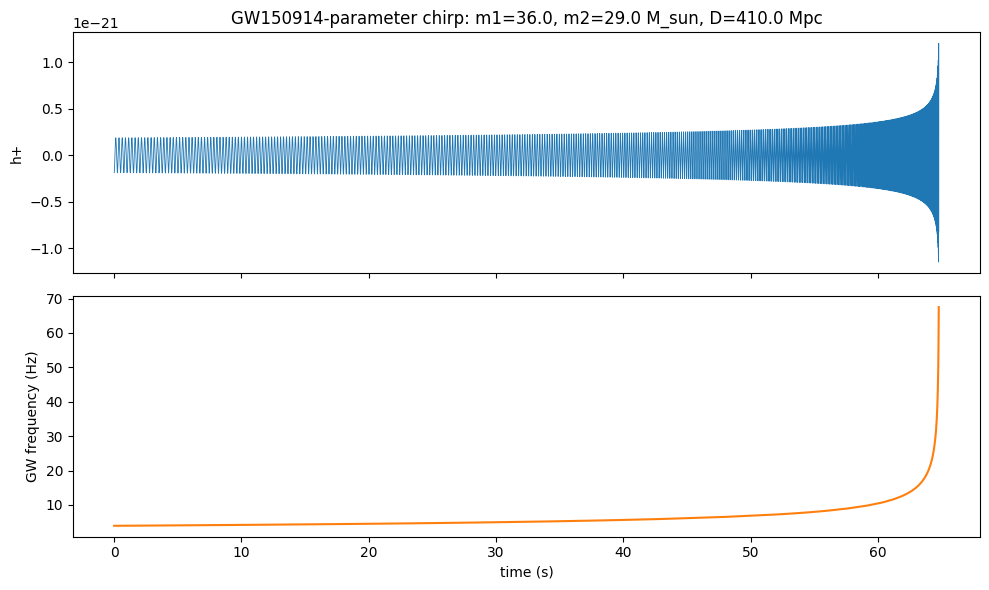

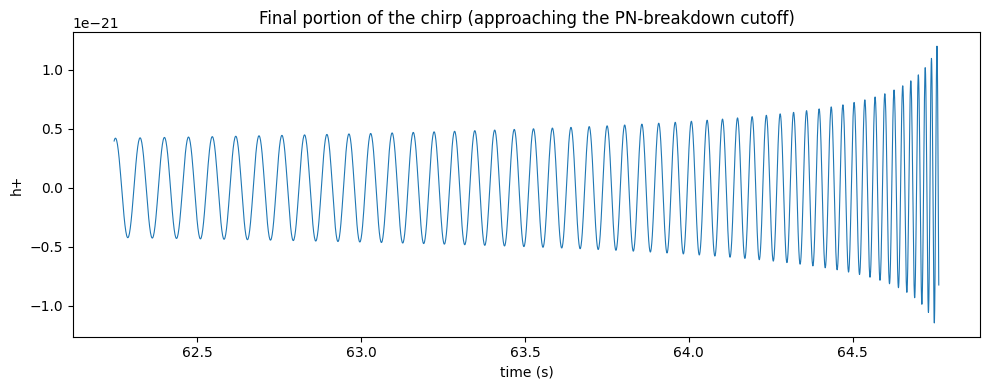

In [4]:
m1_gw, m2_gw = 36.0, 29.0
M_gw = m1_gw + m2_gw
mu_gw = m1_gw*m2_gw/M_gw
D_mpc_gw = 410.0
a0_gw = 40.0 * M_gw

res_gw = pn.integrate_inspiral(m1_gw, m2_gw, a0_gw, e0=0.0)
h_plus_gw, h_cross_gw = wf.strain_plus_cross_SI(res_gw["pos"], res_gw["vel"], res_gw["acc"], mu_gw, D_mpc_gw)
t_gw_s = wf.geometrized_to_seconds(res_gw["t"])
Om_gw = pn.orbital_frequency(res_gw["pos"], res_gw["vel"])
f_gw_hz2 = wf.geometrized_freq_to_hz(2*np.abs(Om_gw))

print(f"total inspiral duration simulated: {t_gw_s[-1]:.3f} s")
print(f"final (cutoff) GW frequency: {f_gw_hz2[-1]:.1f} Hz   (real GW150914 measured peak: ~150-250 Hz -- "
      f"see markdown above for why this simulation's leading-order-PN cutoff undershoots that)")
print(f"peak |h+|: {np.abs(h_plus_gw).max():.3e}   (GW150914's real measured peak strain: ~1.0e-21)")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t_gw_s, h_plus_gw, lw=0.6)
axes[0].set_ylabel("h+")
axes[0].set_title(f"GW150914-parameter chirp: m1={m1_gw}, m2={m2_gw} M_sun, D={D_mpc_gw} Mpc")
axes[1].plot(t_gw_s, f_gw_hz2, color="C1")
axes[1].set_ylabel("GW frequency (Hz)")
axes[1].set_xlabel("time (s)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "gw150914_chirp.png"), dpi=150, bbox_inches="tight")
plt.show()

# zoom on the last portion of the chirp, where amplitude/frequency change is most visible
n_zoom = min(3000, len(t_gw_s))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_gw_s[-n_zoom:], h_plus_gw[-n_zoom:], lw=0.8)
ax.set_xlabel("time (s)"); ax.set_ylabel("h+")
ax.set_title("Final portion of the chirp (approaching the PN-breakdown cutoff)")
fig.tight_layout()
fig.savefig(os.path.join(MEDIA, "gw150914_chirp_zoom.png"), dpi=150, bbox_inches="tight")
plt.show()